In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


import re
import nltk
nltk.download('punkt_tab') #model za tokenizaciju, PREBACITI U preprocessing analysis
nltk.download('stopwords') #model za stop reci


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Iva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Iva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
import pandas as pd

df = pd.read_csv('../data/IMDB Dataset.csv')

print(df.shape)
print(df.head())
print(df.dtypes)
print(df['sentiment'].value_counts())

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
review       str
sentiment    str
dtype: object
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [15]:
print(df['review'][1])

A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.


In [16]:
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

print(f"Average word count: {df['word_count'].mean():.0f}")
print(f"Longest review: {df['word_count'].max()} words")
print(f"Shortest review: {df['word_count'].min()} words")

Average word count: 231
Longest review: 2470 words
Shortest review: 4 words


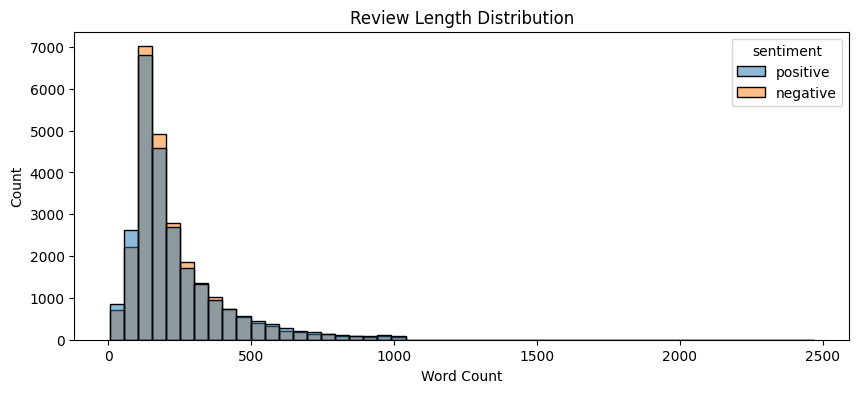

In [17]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='word_count', hue='sentiment', bins=50)
plt.title('Review Length Distribution')
plt.xlabel('Word Count')
plt.show()

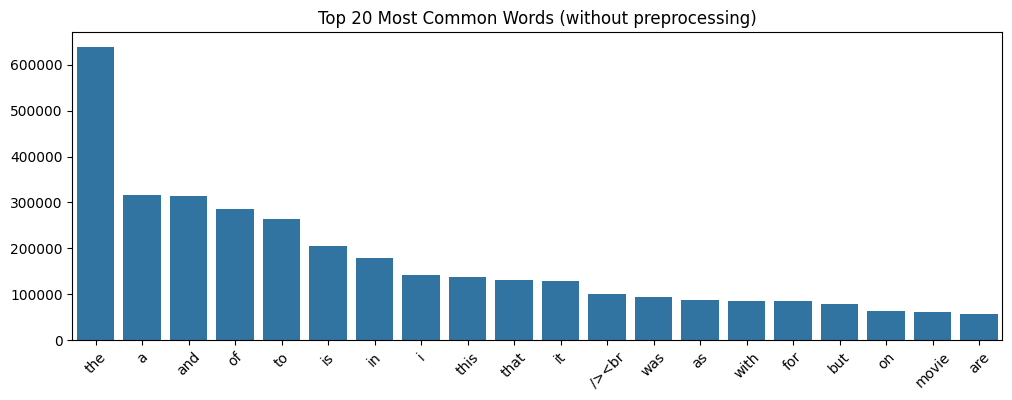

In [18]:
all_words = ' '.join(df['review']).lower().split()
most_common = Counter(all_words).most_common(20)

words, counts = zip(*most_common)
plt.figure(figsize=(12, 4))
sns.barplot(x=list(words), y=list(counts))
plt.title('Top 20 Most Common Words (without preprocessing)')
plt.xticks(rotation=45)
plt.show()

In [19]:
df['has_html'] = df['review'].apply(lambda x: bool(re.search(r'<.*?>', x)))
print(f"Reviews with HTML tags: {df['has_html'].sum()}")

Reviews with HTML tags: 29202


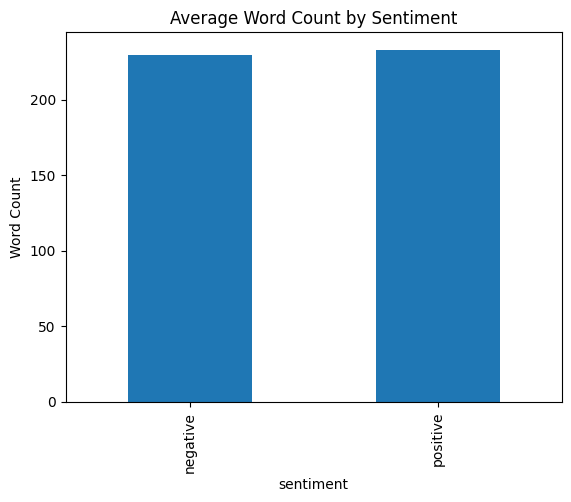

In [12]:
df.groupby('sentiment')['word_count'].mean().plot(kind='bar')
plt.title('Average Word Count by Sentiment')
plt.ylabel('Word Count')
plt.show()

In [20]:
print("=== Short Reviews Analysis ===\n")
print(f"Reviews with ≤5 words:  {df[df['word_count'] <= 5].shape[0]}")
print(f"Reviews with ≤10 words: {df[df['word_count'] <= 10].shape[0]}")
print(f"Reviews with ≤20 words: {df[df['word_count'] <= 20].shape[0]}")

print("\n=== Examples of shortest reviews ===\n")
short = df.nsmallest(10, 'word_count')
for _, row in short.iterrows():
    print(f"Words: {row['word_count']} | Sentiment: {row['sentiment']}")
    print(f"Review: {row['review']}")
    print()

=== Short Reviews Analysis ===

Reviews with ≤5 words:  1
Reviews with ≤10 words: 8
Reviews with ≤20 words: 30

=== Examples of shortest reviews ===

Words: 4 | Sentiment: negative
Review: Primary plot!Primary direction!Poor interpretation.

Words: 6 | Sentiment: negative
Review: Read the book, forget the movie!

Words: 8 | Sentiment: negative
Review: More suspenseful, more subtle, much, much more disturbing....

Words: 8 | Sentiment: negative
Review: I hope this group of film-makers never re-unites.

Words: 9 | Sentiment: negative
Review: What a script, what a story, what a mess!

Words: 10 | Sentiment: negative
Review: I wouldn't rent this one even on dollar rental night.

Words: 10 | Sentiment: positive
Review: Brilliant and moving performances by Tom Courtenay and Peter Finch.

Words: 10 | Sentiment: negative
Review: This movie is terrible but it has some good effects.

Words: 11 | Sentiment: negative
Review: You'd better choose Paul Verhoeven's even if you have watched it.

Words: